# BreaKHis Dataset Exploration

## Objective
This is my first proper pass through BreaKHis before doing any modelling. I want to see how the cohort is distributed, what the images look like at different magnifications, and whether anything in the raw filenames or folder structure changes how I should split the data later.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from PIL import Image
from IPython.display import display

from src.breakhis import build_binary_records, cohort_summary, label_summary

df = build_binary_records(DATA_ROOT)
df.head()


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


,filepath,magnification,label,patient_id,filename
0,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,100X,benign,SOB_B_A-14-22549AB,SOB_B_A-14-22549AB-100-001.png
1,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,100X,benign,SOB_B_A-14-22549AB,SOB_B_A-14-22549AB-100-002.png
2,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,100X,benign,SOB_B_A-14-22549AB,SOB_B_A-14-22549AB-100-003.png
3,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,100X,benign,SOB_B_A-14-22549AB,SOB_B_A-14-22549AB-100-004.png
4,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,100X,benign,SOB_B_A-14-22549AB,SOB_B_A-14-22549AB-100-005.png


## Cohort Structure

The first thing I needed to understand was what the raw directory structure was really telling me. At a glance the dataset looks organised only by label and magnification, but the filenames also carry patient identity. That detail ended up mattering much more than I expected, because once I noticed it, a naive image-level split stopped looking safe.


In [2]:
label_table = label_summary(df)
cohort_table = cohort_summary(df)
label_table.to_csv(REPORTS / 'breakhis_label_summary.csv', index=False)
cohort_table.to_csv(REPORTS / 'breakhis_magnification_summary.csv', index=False)
print('Total images:', len(df))
print('Total patients:', df['patient_id'].nunique())
display(label_table)
display(cohort_table)


Total images: 7909
Total patients: 82


,label,images,patients
0,benign,2480,24
1,malignant,5429,58


,label,magnification,images,patients
0,benign,100X,644,24
1,benign,200X,623,24
2,benign,400X,588,24
3,benign,40X,625,24
4,malignant,100X,1437,58
5,malignant,200X,1390,58
6,malignant,400X,1232,58
7,malignant,40X,1370,58


In [3]:
size_rows = []
for image_path in df['filepath'].sample(n=min(400, len(df)), random_state=SEED):
    with Image.open(image_path) as image:
        width, height = image.size
    size_rows.append({'filepath': image_path, 'width': width, 'height': height})
size_df = pd.DataFrame(size_rows)
size_summary = size_df.groupby(['width', 'height']).size().reset_index(name='count').sort_values('count', ascending=False)
size_summary.to_csv(REPORTS / 'breakhis_image_size_summary.csv', index=False)
size_summary


,width,height,count
0,224,224,400


## Sample Mosaics by Class and Magnification

I wanted to look at the images directly before deciding anything about preprocessing. The magnification changes the apparent texture scale a lot, and the malignant side is visibly larger than the benign side, so it made sense to check those differences with actual examples instead of assuming the dataset was visually uniform.


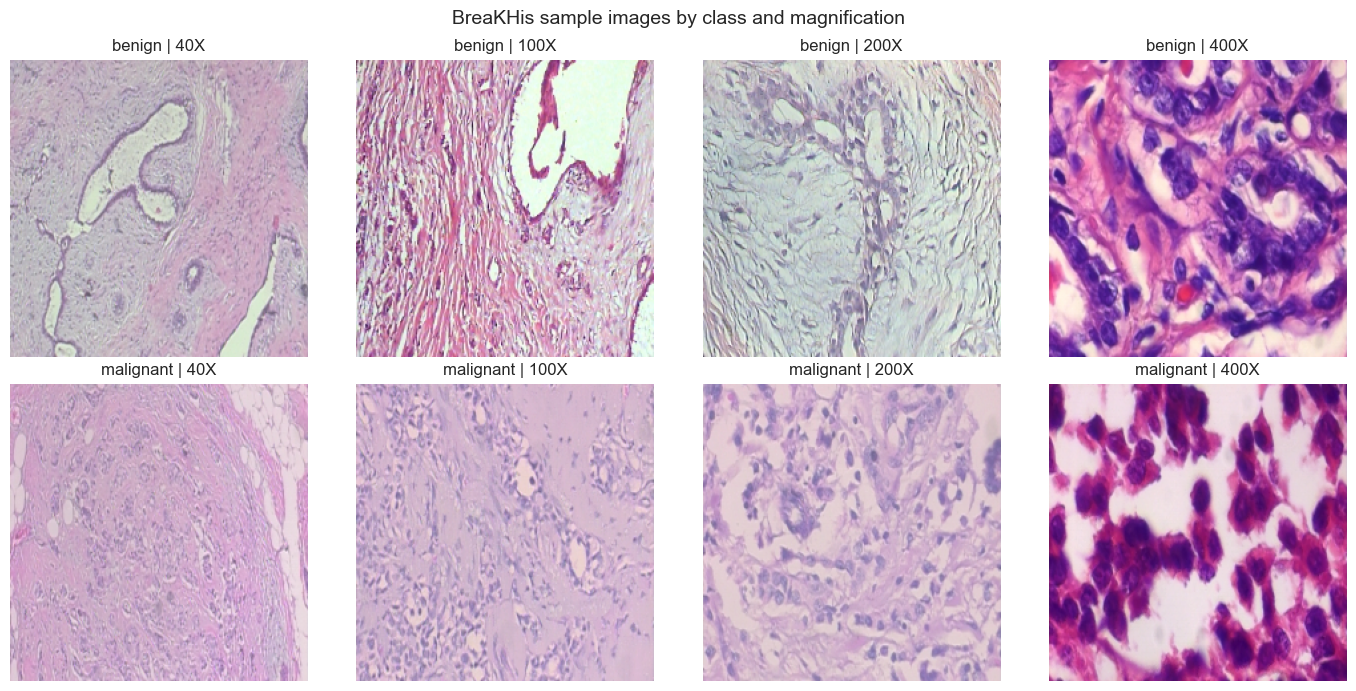

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
labels = ['benign', 'malignant']
mags = ['40X', '100X', '200X', '400X']
for row_idx, label in enumerate(labels):
    for col_idx, magnification in enumerate(mags):
        sample_row = df[(df['label'] == label) & (df['magnification'] == magnification)].sample(1, random_state=SEED).iloc[0]
        with Image.open(sample_row['filepath']) as image:
            image = image.convert('RGB')
            axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(f'{label} | {magnification}')
        axes[row_idx, col_idx].axis('off')
fig.suptitle('BreaKHis sample images by class and magnification', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_sample_mosaic.png', dpi=300, bbox_inches='tight')
plt.show()


In [5]:
colour_rows = []
for image_path in df['filepath'].sample(n=min(256, len(df)), random_state=SEED):
    with Image.open(image_path) as image:
        arr = np.asarray(image.convert('RGB'), dtype=np.float32) / 255.0
    colour_rows.append(arr.reshape(-1, 3).mean(axis=0))
colour_df = pd.DataFrame(colour_rows, columns=['red_mean', 'green_mean', 'blue_mean'])
colour_summary = colour_df.describe().T[['mean', 'std', 'min', 'max']]
colour_summary.to_csv(REPORTS / 'breakhis_colour_summary.csv')
colour_summary


,mean,std,min,max
red_mean,0.787734,0.075345,0.523822,0.983688
green_mean,0.619497,0.112905,0.286063,0.874884
blue_mean,0.762136,0.067641,0.504519,0.940819


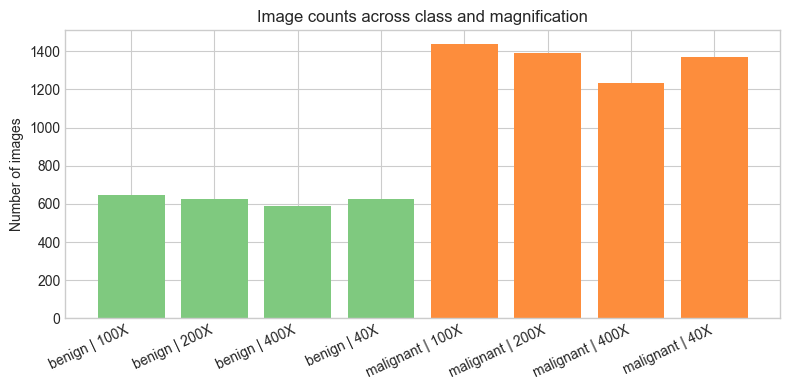

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = cohort_table.copy()
plot_df['label_mag'] = plot_df['label'] + ' | ' + plot_df['magnification']
ax.bar(plot_df['label_mag'], plot_df['images'], color=['#7fc97f' if label == 'benign' else '#fd8d3c' for label in plot_df['label']])
ax.set_title('Image counts across class and magnification')
ax.set_ylabel('Number of images')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_class_magnification_counts.png', dpi=300)
plt.show()


## Interpretation

Three things stood out straight away. The dataset is imbalanced, with far more malignant images than benign ones. The same patient appears across multiple images and magnifications, which means the split has to protect patients rather than just individual files. The magnification differences are also strong enough that a single aggregate number later on will need some support from subgroup analysis. That is what pushed me into checking the split directly in the next notebook.
